In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/raw/products.csv", sep="\t")

In [3]:
df.columns

Index(['product_id', 'name', 'category', 'brand', 'price', 'stock', 'rating'], dtype='object')

In [4]:
df.head()

,product_id,name,category,brand,price,stock,rating
0,1,MacBook Pro M4 14,Laptop,Apple,10677.59,10.0,4.7
1,2,RTX 5070 Ti 16GB,GPU,NVIDIA,771.27,13.0,4.9
2,3,Core Ultra 5 245K,CPU,Intel,323.46,12.0,4.3
3,4,16GB DDR5-5600,RAM,Kingston,50.02,47.0,4.2
4,5,27in 4K OLED 240Hz,Monitor,ASUS,891.3,5.0,4.7


In [5]:
df.shape

(200, 7)

In [6]:
df.dtypes

product_id      int64
name           object
category       object
brand          object
price          object
stock         float64
rating        float64
dtype: object

In [7]:
df.isnull().sum()

product_id    0
name          0
category      0
brand         3
price         2
stock         3
rating        2
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(4)

In [9]:
df["price"].describe()

count        198
unique       191
top       166.92
freq           2
Name: price, dtype: object

In [10]:
df["category"].value_counts()

category
SSD            36
CPU            30
GPU            27
RAM            24
Case           16
Mouse          15
Monitor        14
Motherboard    12
PSU            11
Headset         8
Laptop          7
Name: count, dtype: int64

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

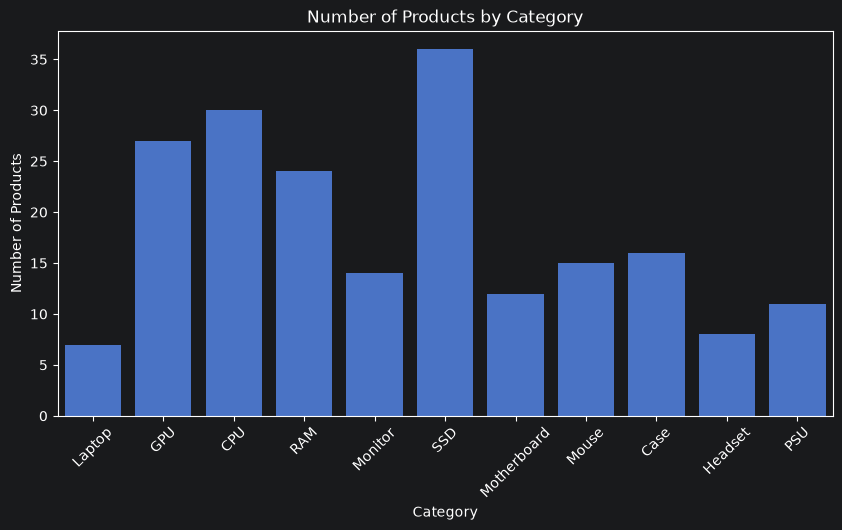

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="category")
plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

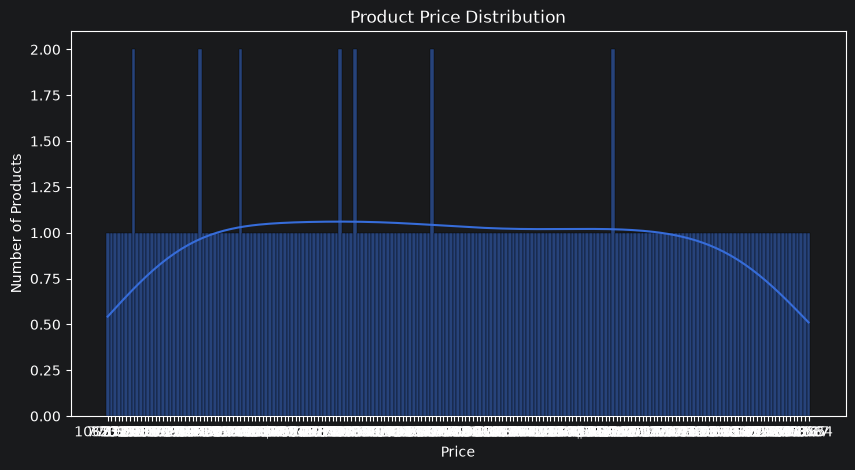

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="price", bins=20, kde=True)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.show()

In [14]:
# category_price = df.groupby("category")["price"].mean()
# print(category_price)
print(df["price"].dtype)
print(df["price"].head(20))
df["price"] = (df["price"].astype(str).str.replace("$","", regex=False))
df["price"] = pd.to_numeric(df["price"], errors="coerce")
print(df["price"].dtype)
category_price = df.groupby("category")["price"].mean()
print(category_price)

object
0     10677.59
1       771.27
2       323.46
3        50.02
4        891.3
5       371.17
6       162.96
7       315.38
8        93.31
9       180.39
10      201.85
11       51.63
12     1971.22
13         NaN
14      354.57
15      597.27
16      154.61
17      386.98
18      161.14
19       77.23
Name: price, dtype: object
float64
category
CPU             369.207000
Case            114.590625
GPU            1115.991538
Headset         278.851250
Laptop         2958.718571
Monitor         675.204286
Motherboard     272.520000
Mouse           156.460667
PSU             147.951818
RAM             116.568750
SSD             130.829167
Name: price, dtype: float64


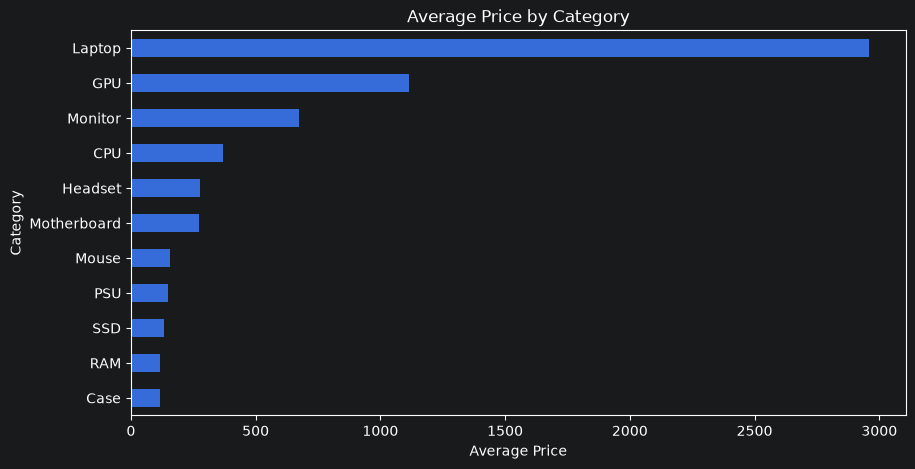

In [15]:
plt.figure(figsize=(10,5))
category_price.sort_values().plot(kind="barh")
plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.show()

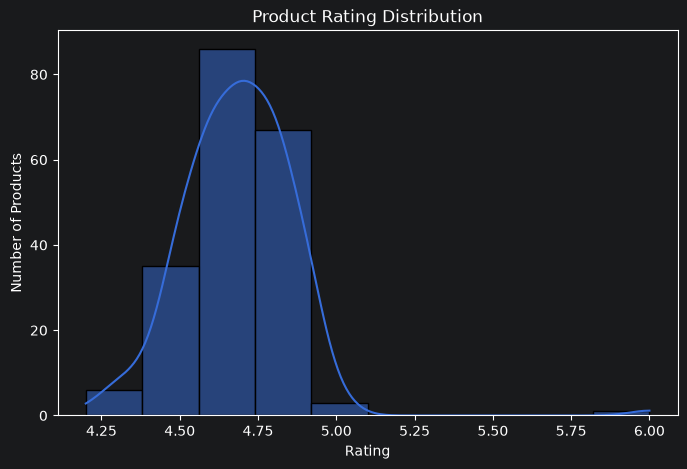

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="rating", bins=10, kde=True)
plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()

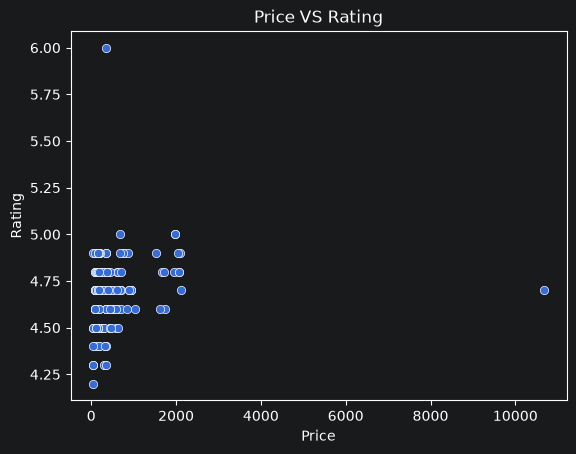

In [17]:
plt.plot(figsize=(8,5))
sns.scatterplot(data=df, x="price", y="rating")
plt.title("Price VS Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

In [18]:
from src.data.preprocessing import clean_products

In [19]:
df_clean = clean_products(df)

In [20]:
df.shape

(200, 7)

In [21]:
df_clean.shape

(188, 7)

In [22]:
df_clean.to_csv("../data/processed/cleaned.csv", index=False)

In [23]:
from src.data.preprocessing import split_data
train_df, val_df, test_df = split_data(df_clean)
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)
train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)
print("Original:", df.shape)
print("Cleaned:", df_clean.shape)
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (150, 7)
Val: (19, 7)
Test: (19, 7)
Original: (200, 7)
Cleaned: (188, 7)
Train: (150, 7)
Val: (19, 7)
Test: (19, 7)


In [24]:
print("Shape:", df_clean.shape)
print("Data Types:", df_clean.dtypes)
print("Null Values:",df_clean.isnull().sum())
print("Duplicates:", df_clean.duplicated().sum())
print("Invalid prices:",(df_clean["price"] <= 0).sum())
print("Invalid stock:", (df_clean["stock"] <0).sum())
invalid_rating = ((df_clean["rating"] < 0) | (df_clean["rating"] > 5).sum())
print("Invalid Rating:", invalid_rating)


Shape: (188, 7)
Data Types: product_id      int64
name           object
category       object
brand          object
price         float64
stock         float64
rating        float64
dtype: object
Null Values: product_id    0
name          0
category      0
brand         3
price         0
stock         0
rating        0
dtype: int64
Duplicates: 0
Invalid prices: 0
Invalid stock: 0
Invalid Rating: 0      False
1      False
2      False
3      False
4      False
       ...  
191    False
192    False
193    False
194    False
195    False
Name: rating, Length: 188, dtype: bool


In [25]:
x = df_clean.drop(columns=["category"])
y = df_clean["category"]
print("x shape:", x.shape)
print("y shape:", y.shape)
print("Target distribution:", y.value_counts())

x shape: (188, 6)
y shape: (188,)
Target distribution: category
SSD            35
CPU            28
GPU            24
RAM            22
Case           16
Mouse          15
Monitor        14
Motherboard    11
PSU            11
Laptop          6
Headset         6
Name: count, dtype: int64


In [26]:
from src.data.preprocessing import split_data
train_df, val_df, test_df = split_data(df_clean)
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)
train_df.to_csv("../data/splits/train.csv", index=False)
val_df.to_csv("../data/splits/validation.csv", index=False)
test_df.to_csv("../data/splits/test.csv", index=False)
print("Train / Validation / Test Files Saved Successfully!")
print(train_df.head())
print(val_df.head())
print(test_df.head())
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))

Train: (150, 7)
Val: (19, 7)
Test: (19, 7)
Train / Validation / Test Files Saved Successfully!
     product_id                  name category     brand    price  stock  \
37           38  G Pro X Superlight 2    Mouse  Logitech   153.56   21.0   
102         103            1TB SN850X      SSD        WD    95.61   22.0   
108         109      ROG Zephyrus G14   Laptop      ASUS  1666.37    8.0   
78           79       RX 9070 XT 16GB      GPU       AMD   617.36   10.0   
97           98     DeathAdder V3 Pro    Mouse     Razer   144.41   12.0   

     rating  
37      4.8  
102     4.8  
108     4.8  
78      4.6  
97      4.6  
     product_id                   name     category    brand   price  stock  \
112         113    B650 Tomahawk WiFi   Motherboard      MSI  189.86   13.0   
128         129     B650 Tomahawk WiFi  Motherboard      MSI  198.05   21.0   
169         170             2TB SN850X          SSD       WD  150.66   22.0   
138         139      Core Ultra 7 265K          

In [27]:
import  pandas as pd
train_df = pd.read_csv("../data/splits/train.csv")
val_df = pd.read_csv("../data/splits/validation.csv")
test_df = pd.read_csv("../data/splits/test.csv")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Testing:", test_df.shape)

Train: (150, 7)
Val: (19, 7)
Testing: (19, 7)


In [28]:
x_train = train_df.drop(columns=["category", "product_id", "name"])
x_val = val_df.drop(columns=["category", "product_id", "name"])
x_test = test_df.drop(columns=["category", "product_id", "name"])

In [29]:
y_train = train_df["category"]
y_val = val_df["category"]
y_test = test_df["category"]

In [30]:
from src.data.preprocessing import create_preprocessor
preprocessor = create_preprocessor()
preprocessor.fit(x_train)
x_train_processed = preprocessor.transform(x_train)
x_val_processed = preprocessor.transform(x_val)
x_test_processed = preprocessor.transform(x_test)
print("Original x_train:", x_train.shape)
print("Processed x_train:", x_train_processed.shape)
print("\nOriginal x_val:", x_val.shape)
print("Processed x_val:", x_val_processed.shape)
print("\nOriginal x_test:", x_test.shape)
print("Processed x_test:", x_test_processed.shape)

Original x_train: (150, 4)
Processed x_train: (150, 27)

Original x_val: (19, 4)
Processed x_val: (19, 27)

Original x_test: (19, 4)
Processed x_test: (19, 27)


In [31]:
from src.ml.classification import create_classification_pipeline
model_pipeline = create_classification_pipeline()
model_pipeline.fit(x_train, y_train)
y_val_pred = model_pipeline.predict(x_val)
y_test_pred = model_pipeline.predict(x_test)


In [32]:
from sklearn.metrics import accuracy_score
lg_val_accuracy = accuracy_score(y_val, y_val_pred)
lg_test_accuracy = accuracy_score(y_test, y_test_pred)
print("Logistic Regression Validation Accuracy:", lg_val_accuracy)
print("Logistic Regression Test Accuracy:", lg_test_accuracy)

Logistic Regression Validation Accuracy: 0.6842105263157895
Logistic Regression Test Accuracy: 0.7368421052631579


In [33]:
print(model_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand']),
                                                 ('numerical', StandardScaler(),
                                                  ['price', 'stock',
                                                   'rating'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


In [34]:
print("Actual:", y_val.iloc[:10].values)
print("Predicted:", y_val_pred[:10])

Actual: ['Motherboard' 'Motherboard' 'SSD' 'CPU' 'RAM' 'SSD' 'SSD' 'Case' 'Mouse'
 'Headset']
Predicted: ['Mouse' 'SSD' 'SSD' 'CPU' 'RAM' 'SSD' 'SSD' 'Case' 'Mouse' 'SSD']


In [35]:
y_val_proba = model_pipeline.predict_proba(x_val)
print(y_val_proba.shape)
print(y_val_proba[0])

(19, 11)
[0.12353523 0.09685092 0.07765069 0.04551272 0.02431973 0.10155682
 0.06276911 0.16915037 0.11929208 0.01800652 0.16135578]


In [36]:
print(model_pipeline.named_steps["model"].classes_)

['CPU' 'Case' 'GPU' 'Headset' 'Laptop' 'Monitor' 'Motherboard' 'Mouse'
 'PSU' 'RAM' 'SSD']


In [37]:
print("Validation Accuracy:", lg_val_accuracy)
print("\nActual:")
print(y_val.iloc[:10].values)
print("\nPredicted:")
print(y_val_pred[:10])
print("\nClasses:")
print(model_pipeline.named_steps["model"].classes_)
print("\nProbability shape:")
print(model_pipeline.predict_proba(x_val).shape)
print("\nFirst sample probabilities:")
print(model_pipeline.predict_proba(x_val)[0])

Validation Accuracy: 0.6842105263157895

Actual:
['Motherboard' 'Motherboard' 'SSD' 'CPU' 'RAM' 'SSD' 'SSD' 'Case' 'Mouse'
 'Headset']

Predicted:
['Mouse' 'SSD' 'SSD' 'CPU' 'RAM' 'SSD' 'SSD' 'Case' 'Mouse' 'SSD']

Classes:
['CPU' 'Case' 'GPU' 'Headset' 'Laptop' 'Monitor' 'Motherboard' 'Mouse'
 'PSU' 'RAM' 'SSD']

Probability shape:
(19, 11)

First sample probabilities:
[0.12353523 0.09685092 0.07765069 0.04551272 0.02431973 0.10155682
 0.06276911 0.16915037 0.11929208 0.01800652 0.16135578]


In [38]:
from sklearn.metrics import classification_report
report = classification_report(y_val, y_val_pred, zero_division=0)
print(report)

              precision    recall  f1-score   support

         CPU       1.00      1.00      1.00         2
        Case       1.00      1.00      1.00         2
         GPU       1.00      1.00      1.00         1
     Headset       0.00      0.00      0.00         3
     Monitor       0.33      1.00      0.50         1
 Motherboard       1.00      0.25      0.40         4
       Mouse       0.50      1.00      0.67         1
         RAM       1.00      1.00      1.00         2
         SSD       0.50      1.00      0.67         3

    accuracy                           0.68        19
   macro avg       0.70      0.81      0.69        19
weighted avg       0.70      0.68      0.62        19



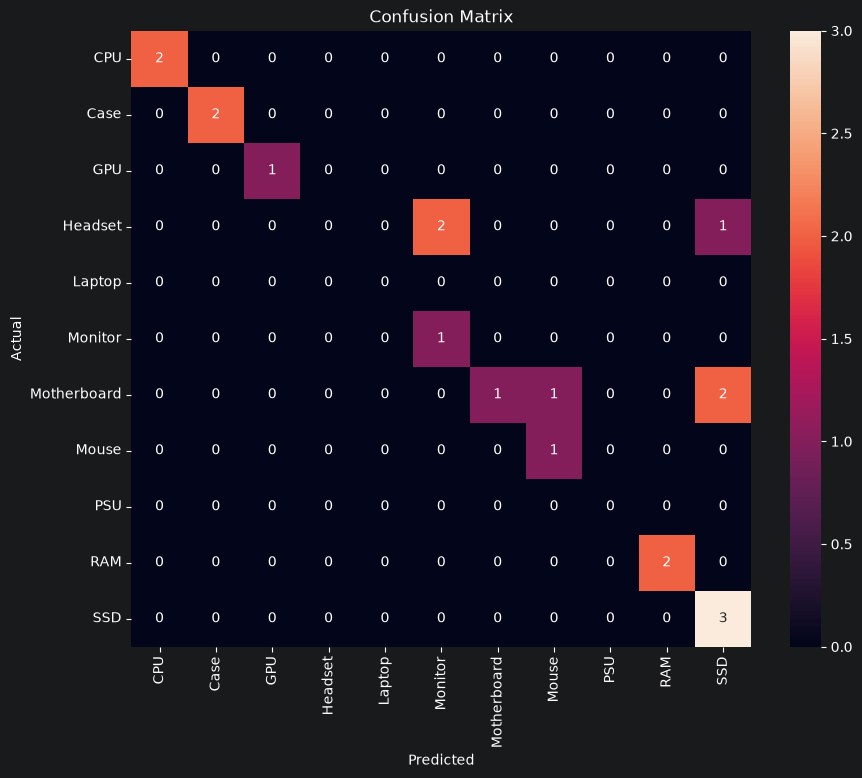

In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_val, y_val_pred, labels=model_pipeline.named_steps["model"].classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=model_pipeline.named_steps["model"].classes_,
            yticklabels=model_pipeline.named_steps["model"].classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [40]:
from sklearn.metrics import accuracy_score, classification_report
y_test_pred = model_pipeline.predict(x_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_accuracy)
print("Classification Report:", classification_report(y_test, y_test_pred, zero_division=0))

Test Accuracy: 0.7368421052631579
Classification Report:               precision    recall  f1-score   support

         CPU       1.00      1.00      1.00         4
        Case       1.00      0.75      0.86         4
         GPU       1.00      1.00      1.00         2
     Headset       0.00      0.00      0.00         1
      Laptop       0.00      0.00      0.00         1
     Monitor       0.00      0.00      0.00         0
 Motherboard       0.00      0.00      0.00         1
         PSU       1.00      1.00      1.00         2
         RAM       0.00      0.00      0.00         1
         SSD       0.60      1.00      0.75         3

    accuracy                           0.74        19
   macro avg       0.46      0.47      0.46        19
weighted avg       0.73      0.74      0.72        19



In [41]:
import importlib
import src.ml.classification as classification
importlib.reload(classification)

print(classification.__file__)
print("Random Forest function:",
      hasattr(classification, "create_random_forest_pipeline"))
create_random_forest_pipeline = classification.create_random_forest_pipeline
rf_pipeline = create_random_forest_pipeline()

rf_pipeline.fit(
    x_train,
    y_train
)

y_val_pred_rf = rf_pipeline.predict(x_val)

/Users/macbookpro/PycharmProjects/Techcart_ai/src/ml/classification.py
Random Forest function: True


In [42]:
from sklearn.metrics import accuracy_score
rf_val_accuracy = accuracy_score(y_val, y_val_pred_rf)
print("Random Forest Validation Accuracy:", rf_val_accuracy)

Random Forest Validation Accuracy: 0.8947368421052632


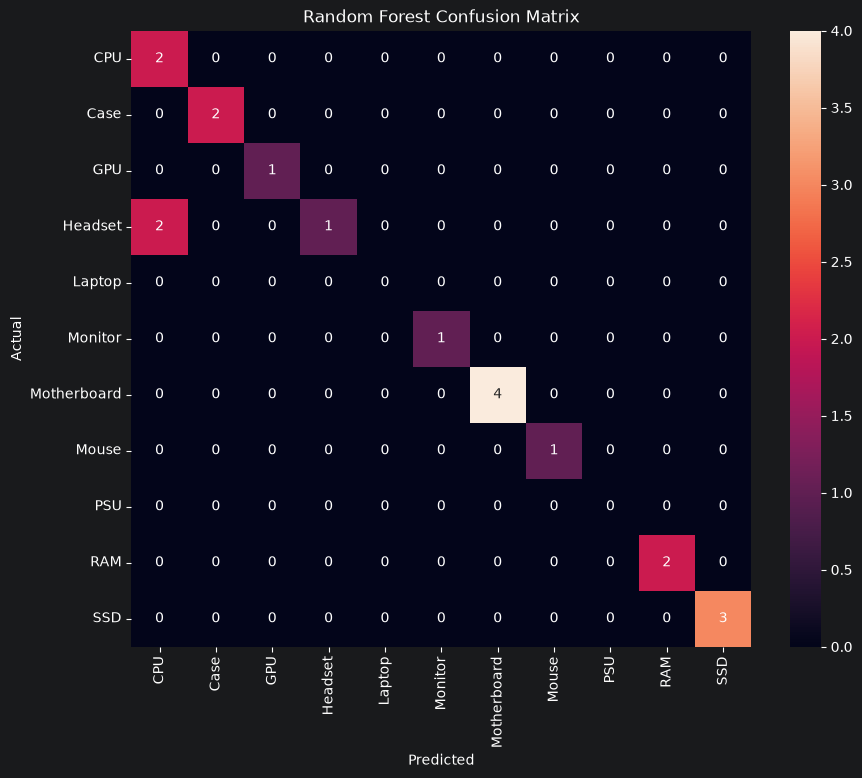

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_rf = confusion_matrix(y_val, y_val_pred_rf, labels=rf_pipeline.named_steps["model"].classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt="d", xticklabels=rf_pipeline.named_steps["model"].classes_,
            yticklabels=rf_pipeline.named_steps["model"].classes_)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [44]:
y_test_pred_rf = rf_pipeline.predict(x_test)
from sklearn.metrics import accuracy_score
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)
print("Random Forest Test Accuracy:", rf_test_accuracy)


Random Forest Test Accuracy: 0.8421052631578947


In [45]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_test_pred_rf, zero_division=0)
print(report)

              precision    recall  f1-score   support

         CPU       0.80      1.00      0.89         4
        Case       1.00      0.75      0.86         4
         GPU       1.00      1.00      1.00         2
     Headset       0.00      0.00      0.00         1
      Laptop       1.00      1.00      1.00         1
 Motherboard       1.00      1.00      1.00         1
         PSU       1.00      1.00      1.00         2
         RAM       0.00      0.00      0.00         1
         SSD       0.60      1.00      0.75         3

    accuracy                           0.84        19
   macro avg       0.71      0.75      0.72        19
weighted avg       0.79      0.84      0.80        19



In [46]:
print("===MODEL COMPARISON===")
print("Logistic Regression Validation Accuracy:", lg_val_accuracy)
print("Logistic Regression Test Accuracy:", lg_test_accuracy)
print("Random Forest Validation Accuracy:", rf_val_accuracy)
print("Random Forest Test Accuracy:", rf_test_accuracy)

===MODEL COMPARISON===
Logistic Regression Validation Accuracy: 0.6842105263157895
Logistic Regression Test Accuracy: 0.7368421052631579
Random Forest Validation Accuracy: 0.8947368421052632
Random Forest Test Accuracy: 0.8421052631578947
